# Simplified hierarchical morphotope classification (HiMoC)

In [1]:
import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import momepy
import shapely
import neatnet

Pick a place, ideally a town with a good coverage in OpenStreetMap and its local CRS.

In [2]:
place = "Norwich, UK"
epsg_uk = 27700

In [3]:
# norwich_centre = gpd.tools.geocode(place)

norwich_centre = gpd.GeoSeries(
    [shapely.Point(1.29626, 52.62858)], name="geometry", crs="epsg:4326"
)

In [4]:
norwich_radius = norwich_centre.to_crs(epsg=epsg_uk).buffer(1_500)

In [5]:
from overturemaps import record_batch_reader

In [6]:
reader = record_batch_reader(
    "building", bbox=tuple(norwich_radius.to_crs(epsg=4326).bounds.values[0])
)

In [7]:
res = reader.read_all()

In [8]:
import geopandas as gpd

buildings = gpd.GeoDataFrame.from_arrow(res)
buildings = buildings.set_crs(epsg=4326)

## Input data

We can use ``OSMnx`` to quickly download data from OpenStreetMap. If you intend to download larger areas, we recommend using ``pyrosm`` instead.

### Buildings

In [9]:
buildings.geom_type.value_counts()

Polygon         13899
MultiPolygon        4
Name: count, dtype: int64

In [10]:
buildings = buildings[buildings.geom_type == "Polygon"].reset_index(drop=True)

And we should re-project the data from WGS84 to the local projection in meters (momepy default values assume meters not feet or degrees). We will also drop unnecessary columns.

In [11]:
buildings = buildings[["geometry"]].to_crs(epsg=27700)
buildings.head()

,geometry
0,"POLYGON ((621728.302 307213.611, 621741.592 30..."
1,"POLYGON ((621751.175 307251.207, 621755.383 30..."
2,"POLYGON ((621722.104 307299.256, 621725.2 3072..."
3,"POLYGON ((621724.377 307380.839, 621732.358 30..."
4,"POLYGON ((621729.937 307375.632, 621743.854 30..."


### Streets

Similar operations are done with streets.

In [12]:
reader = record_batch_reader(
    "segment", bbox=tuple(norwich_radius.to_crs(epsg=4326).bounds.values[0])
)

In [13]:
res = reader.read_all()

In [14]:
streets = gpd.GeoDataFrame.from_arrow(res)
streets = streets.set_crs(epsg=4326)
streets

,id,geometry,bbox,version,sources,subtype,class,names,connectors,routes,...,access_restrictions,level_rules,destinations,prohibited_transitions,road_surface,road_flags,speed_limits,width_rules,subclass,rail_flags
0,0c43ec60-6ecc-48d1-b7f8-798251a31962,"LINESTRING (0.9871 52.22243, 0.98683 52.22395,...","{'xmin': 0.9867087006568909, 'xmax': 1.3157254...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",rail,standard_gauge,"{'primary': 'Great Eastern Main Line', 'common...",[{'connector_id': 'ef0d8fc2-83e3-4f24-b37a-9ed...,None,...,None,"[{'value': 1, 'between': [0.005976654, 0.00644...",None,None,None,None,None,None,None,"[{'values': ['is_bridge'], 'between': [0.00597..."
1,a66c5a5e-c284-4e7f-99c4-7b99966b1938,"LINESTRING (1.2709 52.61543, 1.27093 52.61537,...","{'xmin': 1.2709006071090698, 'xmax': 1.2750113...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,footway,None,[{'connector_id': 'd0ab73fe-737a-4b8e-a13a-b1b...,None,...,None,None,None,None,None,None,None,None,None,None
2,d996c25b-4b0a-4a6c-93af-5f5f0981b854,"LINESTRING (1.27438 52.6159, 1.27394 52.61623,...","{'xmin': 1.273413896560669, 'xmax': 1.27437710...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,cycleway,None,[{'connector_id': '36ea076b-9f29-4a85-84a1-7be...,None,...,"[{'access_type': 'designated', 'when': {'durin...",None,None,None,"[{'value': 'unknown', 'between': None}]",None,None,None,None,None
3,64ae9328-d01a-4c78-afc7-8208ae127751,"LINESTRING (1.27429 52.61611, 1.27416 52.61617...","{'xmin': 1.2738310098648071, 'xmax': 1.2742880...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,trunk,"{'primary': 'Daniels Road', 'common': None, 'r...",[{'connector_id': '5bfbf655-53e9-407f-801f-017...,"[{'name': 'A140 Road (Great Britain)', 'networ...",...,"[{'access_type': 'denied', 'when': {'during': ...",None,None,None,None,None,"[{'min_speed': None, 'max_speed': {'value': 40...",None,None,None
4,95456ade-d823-4a7e-bb84-5c0d6be903a8,"LINESTRING (1.27446 52.61627, 1.27443 52.61625...","{'xmin': 1.2743500471115112, 'xmax': 1.2744650...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",road,path,None,[{'connector_id': '78f1cefd-2b52-4833-aee0-ddb...,None,...,"[{'access_type': 'allowed', 'when': {'during':...",None,None,None,"[{'value': 'paved', 'between': None}]",None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6175,b4a4e879-e138-41c0-8617-8dff497a3d9e,"LINESTRING (-0.27947 53.74078, -0.27968 53.739...","{'xmin': -0.27968502044677734, 'xmax': 4.13156...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",water,None,"{'primary': 'Hull - Rotterdam', 'common': None...",[{'connector_id': '6f9a1d6f-4ecc-49b8-b1f9-e33...,None,...,None,None,None,None,None,None,None,None,None,None
6176,e7ddbc8f-2e03-4424-96ef-c1d719197143,"LINESTRING (4.13453 51.97213, 4.13534 51.97157...","{'xmin': -0.23199042677879333, 'xmax': 4.13553...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",water,None,"{'primary': 'Hoek van Holland - Killingholme',...",[{'connector_id': '7fbd6b20-88ee-4680-9b4f-c18...,None,...,None,None,None,None,None,None,None,None,None,None
6177,fffbc12f-a485-4be3-aac2-8c35b92869db,"LINESTRING (4.36196 51.9054, 4.36457 51.90266,...","{'xmin': -0.20152312517166138, 'xmax': 4.36493...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",water,None,"{'primary': 'Rotterdam-Immingham', 'common': N...",[{'connector_id': '8d2abcf6-ad7c-4073-88e3-1de...,None,...,None,None,None,None,None,None,None,None,None,None
6178,58b06bdb-5e8a-47b8-b2c6-a548983b4357,"LINESTRING (-1.14874 54.59896, -1.14953 54.599...","{'xmin': -1.1601976156234741, 'xmax': 4.129732...",1,"[{'property': '', 'dataset': 'OpenStreetMap', ...",water,None,"{'primary': 'Europoort - Teesport', 'common': ...",[{'connector_id': 'a66385ab-9fd2-439e-8703-c01...,None,...,None,None,None,None,None,None,None,None,None,None


We can also do some preprocessing using momepy to ensure we have proper network topology.

In [15]:
## service road removed
approved_roads = [
    "living_street",
    "motorway",
    "motorway_link",
    "pedestrian",
    "primary",
    "primary_link",
    "residential",
    "secondary",
    "secondary_link",
    "tertiary",
    "tertiary_link",
    "trunk",
    "trunk_link",
    "unclassified",
]
streets = streets[streets["class"].isin(approved_roads)]

In [16]:
def to_drop_tunnel(row):
    """Find whether or not a road segment has a tunnel thats more than 50 metres."""
    tunnel_length = row.geometry.length
    flags = row.road_flags

    total_tunnel_proportion = -1
    for flag in flags:
        if "values" in flag and ("is_tunnel" in flag["values"]):
            # between could be missing to show the whole thing is a tunnel
            total_tunnel_proportion = (
                0.0 if total_tunnel_proportion < 0 else total_tunnel_proportion
            )
            # betweencould be None to indicate the whole thing is a tunnel
            if ("between" in flag) and (flag["between"] is not None):
                s, e = flag["between"][0], flag["between"][1]
                total_tunnel_proportion += e - s

    if (
        total_tunnel_proportion * tunnel_length
    ) > 50 or total_tunnel_proportion == 0.0:
        return True
    return False

In [17]:
## drop tunnels
to_filter = streets.loc[~streets.road_flags.isna(),].to_crs(epsg=epsg_uk)
tunnels_to_drop = to_filter.apply(to_drop_tunnel, axis=1)
streets = streets.drop(to_filter[tunnels_to_drop].index)

In [18]:
streets = streets.to_crs(epsg=epsg_uk)
streets = streets.sort_values("id")[["id", "geometry", "class"]].reset_index(
    drop=True
)

In [19]:
## simplify
simplified = neatnet.neatify(
    streets,
    exclusion_mask=buildings.geometry,
    artifact_threshold_fallback=7,
)

## Generated data

### Tessellation

Given building footprints:

In [20]:
import pandas as pd
import shapely

In [21]:
idxs = (
    pd.DataFrame(shapely.get_coordinates(buildings.representative_point()))
    .drop_duplicates()
    .index
)
limit = momepy.buffered_limit(buildings.loc[idxs], "adaptive")

In [22]:
tessellation = momepy.morphological_tessellation(buildings, clip=limit)

OpenStreetMap data are often problematic due to low quality of some polygons. If some collapse, we get a mismatch between the length of buildings and the length of polygons.

In [23]:
collapsed, _ = momepy.verify_tessellation(tessellation, buildings)

/tmp/ipykernel_105329/3509021287.py:1: UserWarning: Tessellation does not fully match buildings. 1 element(s) disappeared during generation. Index of the affected elements: Index([8679], dtype='int64').
  collapsed, _ = momepy.verify_tessellation(tessellation, buildings)
/tmp/ipykernel_105329/3509021287.py:1: UserWarning: Tessellation contains MultiPolygon elements. Initial objects should  be edited. Index of affected elements: [1319, 1327, 1328, 1329, 1330, 1339, 1340, 1341, 1342, 2360, 2614, 3607, 3608, 4396, 4443, 4444, 4446, 4448, 4485, 4489, 4714, 4946, 4948, 4974, 5057, 5566, 5638, 6098, 7123, 7520, 7632, 8074, 8076, 8083, 8104, 10926, 10927, 10928, 10930, 11196, 11438, 12131, 12132, 12133, 12158, 12651, 12652, 12667, 12670, 12671, 12672, 12847, 12990, 13516, 13754, 13756, 13758, 13788, 13789, 13790].
  collapsed, _ = momepy.verify_tessellation(tessellation, buildings)


In [24]:
idxs = (
    pd.DataFrame(shapely.get_coordinates(buildings.representative_point()))
    .drop_duplicates()
    .index
)

Better to drop affected buildings and re-create tessellation.

In [25]:
buildings = buildings.drop(collapsed).reset_index(drop=True)
idxs = (
    pd.DataFrame(shapely.get_coordinates(buildings.representative_point()))
    .drop_duplicates()
    .index
)
limit = momepy.buffered_limit(buildings.iloc[idxs], "adaptive")

tessellation = momepy.morphological_tessellation(buildings, clip=limit)

Check the result.

In [26]:
tessellation.shape[0] == buildings.shape[0]

True

### Link streets

Link unique IDs of streets to buildings and tessellation cells based on the nearest neighbor join.

In [27]:
buildings["street_index"] = momepy.get_nearest_street(
    buildings, streets, max_distance=100
)
buildings

,geometry,street_index
0,"POLYGON ((621728.302 307213.611, 621741.592 30...",73.0
1,"POLYGON ((621751.175 307251.207, 621755.383 30...",311.0
2,"POLYGON ((621722.104 307299.256, 621725.2 3072...",311.0
3,"POLYGON ((621724.377 307380.839, 621732.358 30...",311.0
4,"POLYGON ((621729.937 307375.632, 621743.854 30...",311.0
...,...,...
13893,"POLYGON ((624644.157 309224.287, 624649.052 30...",401.0
13894,"POLYGON ((624628.74 309657.74, 624633.794 3096...",NaN
13895,"POLYGON ((624630.761 309824.434, 624626.304 30...",NaN
13896,"POLYGON ((624624.158 309831.651, 624618.604 30...",NaN


Aattach the network index to the tessellation as well.

In [28]:
tessellation["street_index"] = buildings["street_index"]

## Measure

Measure individual morphometric characters. For details see the User Guide and the API reference.

### Dimensions

In [29]:
buildings["building_area"] = buildings.area
tessellation["tess_area"] = tessellation.area
streets["length"] = streets.length

### Shape

In [30]:
buildings["eri"] = momepy.equivalent_rectangular_index(buildings)
buildings["elongation"] = momepy.elongation(buildings)
tessellation["convexity"] = momepy.convexity(tessellation)
streets["linearity"] = momepy.linearity(streets)

In [31]:
# fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# buildings.plot("eri", ax=ax[0], scheme="natural_breaks", legend=True)
# buildings.plot("elongation", ax=ax[1], scheme="natural_breaks", legend=True)

# ax[0].set_axis_off()
# ax[1].set_axis_off()

In [32]:
# fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# tessellation.plot("convexity", ax=ax[0], scheme="natural_breaks", legend=True)
# streets.plot("linearity", ax=ax[1], scheme="natural_breaks", legend=True)

# ax[0].set_axis_off()
# ax[1].set_axis_off()

### Spatial distribution

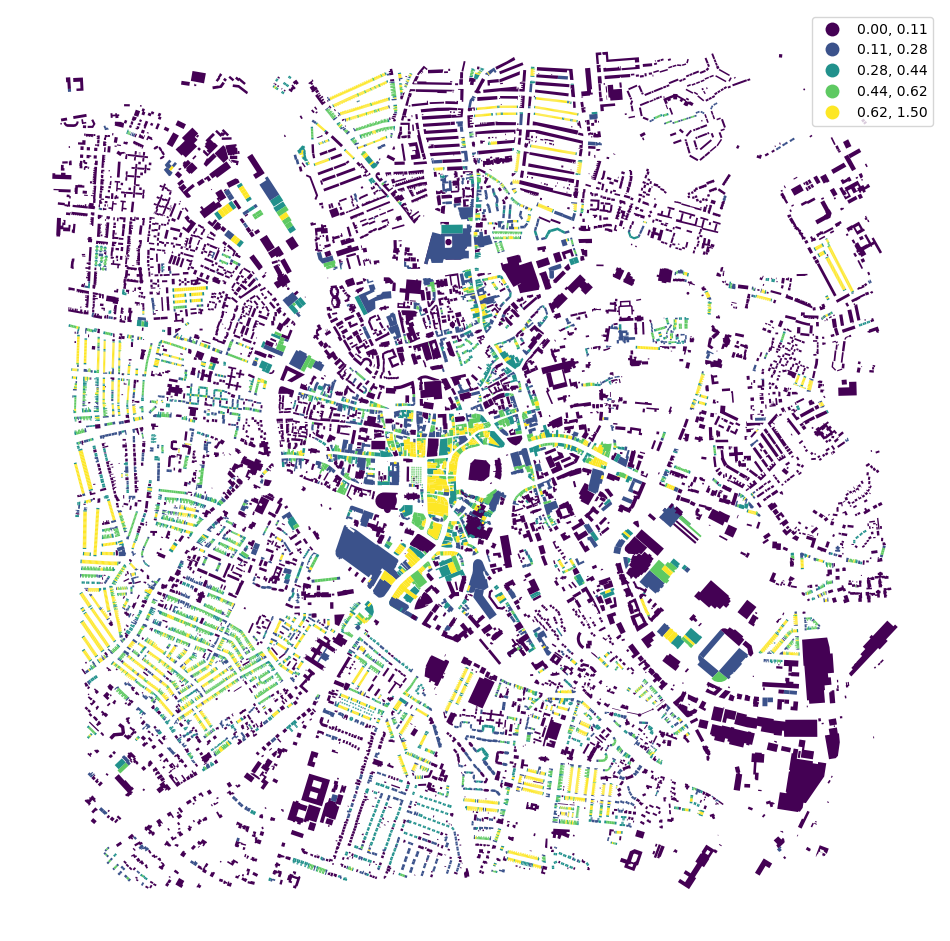

In [33]:
buildings["shared_walls"] = momepy.shared_walls(buildings) / buildings.length
buildings.plot(
    "shared_walls", figsize=(12, 12), scheme="natural_breaks", legend=True
).set_axis_off()

Generate spatial graph using `libpysal`.

In [34]:
queen_1 = libpysal.graph.Graph.build_contiguity(tessellation, rook=False)

In [35]:
queen_1

<Graph of 13898 nodes and 82720 nonzero edges indexed by
 [0, 1, 2, 3, 4, ...]>

In [36]:
queen_1 = libpysal.graph.Graph.build_fuzzy_contiguity(tessellation, buffer=.5)
queen_1

<Graph of 13898 nodes and 88432 nonzero edges indexed by
 [0, 1, 2, 3, 4, ...]>

In [37]:
tessellation["neighbors"] = momepy.neighbors(
    tessellation, queen_1, weighted=True
)
tessellation["covered_area"] = queen_1.describe(tessellation.area)["sum"]
buildings["neighbor_distance"] = momepy.neighbor_distance(buildings, queen_1)

In [38]:
# fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# buildings.plot(
#     "neighbor_distance", ax=ax[0], scheme="natural_breaks", legend=True
# )
# tessellation.plot(
#     "covered_area", ax=ax[1], scheme="natural_breaks", legend=True
# )

# ax[0].set_axis_off()
# ax[1].set_axis_off()

In [39]:
queen_3 = queen_1.higher_order(3)
buildings_q1 = libpysal.graph.Graph.build_contiguity(buildings, rook=False)

buildings["interbuilding_distance"] = momepy.mean_interbuilding_distance(
    buildings, queen_1, queen_3
)
buildings["adjacency"] = momepy.building_adjacency(buildings_q1, queen_3)

In [40]:
# fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# buildings.plot(
#     "interbuilding_distance", ax=ax[0], scheme="natural_breaks", legend=True
# )
# buildings.plot("adjacency", ax=ax[1], scheme="natural_breaks", legend=True)

# ax[0].set_axis_off()
# ax[1].set_axis_off()

In [41]:
profile = momepy.street_profile(streets, buildings)
streets[profile.columns] = profile

In [42]:
# fig, ax = plt.subplots(1, 3, figsize=(24, 12))

# streets.plot("width", ax=ax[0], scheme="natural_breaks", legend=True)
# streets.plot("width_deviation", ax=ax[1], scheme="natural_breaks", legend=True)
# streets.plot("openness", ax=ax[2], scheme="natural_breaks", legend=True)

# ax[0].set_axis_off()
# ax[1].set_axis_off()
# ax[2].set_axis_off()

### Intensity

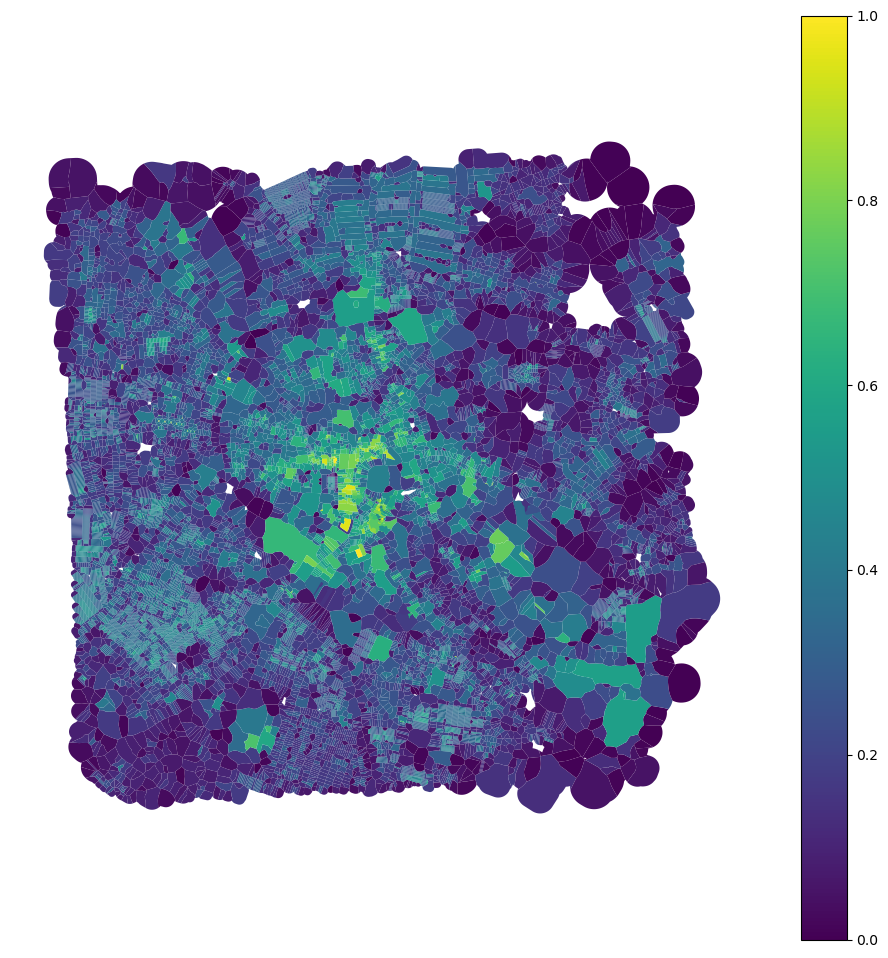

In [43]:
tessellation["car"] = buildings.area / tessellation.area
tessellation.plot(
    "car", figsize=(12, 12), vmin=0, vmax=1, legend=True
).set_axis_off()

### Connectivity

In [44]:
graph = momepy.gdf_to_nx(streets)
graph = momepy.node_degree(graph)
graph = momepy.closeness_centrality(graph, radius=400, distance="mm_len")
graph = momepy.meshedness(graph, radius=400, distance="mm_len")
nodes, edges = momepy.nx_to_gdf(graph)

  0%|          | 0/1868 [00:00<?, ?it/s]

  0%|          | 0/1868 [00:00<?, ?it/s]

In [45]:
# fig, ax = plt.subplots(1, 3, figsize=(24, 12))

# nodes.plot(
#     "degree", ax=ax[0], scheme="natural_breaks", legend=True, markersize=1
# )
# nodes.plot(
#     "closeness",
#     ax=ax[1],
#     scheme="natural_breaks",
#     legend=True,
#     markersize=1,
#     legend_kwds={"fmt": "{:.6f}"},
# )
# nodes.plot(
#     "meshedness", ax=ax[2], scheme="natural_breaks", legend=True, markersize=1
# )

# ax[0].set_axis_off()
# ax[1].set_axis_off()
# ax[2].set_axis_off()

In [46]:
buildings["edge_index"] = momepy.get_nearest_street(buildings, edges)
buildings["node_index"] = momepy.get_nearest_node(
    buildings, nodes, edges, buildings["edge_index"]
)

Link all data together (to tessellation cells or buildings).

In [47]:
tessellation.head()

,geometry,street_index,tess_area,convexity,neighbors,covered_area,car
0,"POLYGON ((621671.783 307235.44, 621707.438 307...",73.0,9054.653507,0.991103,0.025065,18455.207963,0.028037
1,"POLYGON ((621671.783 307235.44, 621698.037 307...",311.0,1942.722056,0.901901,0.013507,18134.261650,0.121884
2,"POLYGON ((621719.064 307338.623, 621722.999 30...",311.0,7687.626466,0.933057,0.015500,17471.890814,0.086097
3,"POLYGON ((621756.923 307427.963, 621764.049 30...",311.0,3903.348436,0.963020,0.015037,10372.113277,0.037822
4,"POLYGON ((621764.045 307426.139, 621764.297 30...",311.0,872.166468,0.728944,0.017951,10242.875223,0.137255


In [48]:
buildings.head()

,geometry,street_index,building_area,eri,elongation,shared_walls,neighbor_distance,interbuilding_distance,adjacency,edge_index,node_index
0,"POLYGON ((621728.302 307213.611, 621741.592 30...",73.0,253.862892,1.000098,0.813069,0.000000,59.313018,32.264802,0.846154,283.0,141.0
1,"POLYGON ((621751.175 307251.207, 621755.383 30...",311.0,236.786818,0.916510,0.582728,0.000000,13.306330,25.756642,0.750000,936.0,485.0
2,"POLYGON ((621722.104 307299.256, 621725.2 3072...",311.0,661.884481,0.635445,0.680802,0.000000,40.874790,38.934024,0.764706,936.0,559.0
3,"POLYGON ((621724.377 307380.839, 621732.358 30...",311.0,147.631470,0.860203,0.565855,0.191035,43.356720,29.990108,0.857143,936.0,559.0
4,"POLYGON ((621729.937 307375.632, 621743.854 30...",311.0,119.708828,0.893382,0.394895,0.206620,28.990782,28.732173,0.863636,936.0,559.0


In [49]:
tessellation[buildings.columns.drop(["geometry", "street_index"])] = (
    buildings.drop(columns=["geometry", "street_index"])
)
merged = tessellation.merge(
    edges.drop(columns="geometry"),
    left_on="edge_index",
    right_index=True,
    how="left",
)
merged = merged.merge(
    nodes.drop(columns="geometry"),
    left_on="node_index",
    right_index=True,
    how="left",
)

In [50]:
merged.columns

Index(['geometry', 'street_index', 'tess_area', 'convexity', 'neighbors',
       'covered_area', 'car', 'building_area', 'eri', 'elongation',
       'shared_walls', 'neighbor_distance', 'interbuilding_distance',
       'adjacency', 'edge_index', 'node_index', 'id', 'class', 'length',
       'linearity', 'width', 'openness', 'width_deviation', 'mm_len',
       'node_start', 'node_end', 'x', 'y', 'degree', 'closeness', 'meshedness',
       'nodeID'],
      dtype='object')

In [51]:
attr_columns = merged.columns.drop(
    [
        "street_index",
        "node_index",
        "edge_index",
        "nodeID",
        "mm_len",
        "node_start",
        "node_end",
        "geometry",
        "x",
        "y",
        "id",
        "class",
    ]
)

In [52]:
merged[attr_columns]

,tess_area,convexity,neighbors,covered_area,car,building_area,eri,elongation,shared_walls,neighbor_distance,interbuilding_distance,adjacency,length,linearity,width,openness,width_deviation,degree,closeness,meshedness
0,9054.653507,0.991103,0.025065,18455.207963,0.028037,253.862892,1.000098,0.813069,0.000000,59.313018,32.264802,0.846154,32.895406,0.999222,50.000000,1.000000,NaN,2,0.000051,0.025641
1,1942.722056,0.901901,0.013507,18134.261650,0.121884,236.786818,0.916510,0.582728,0.000000,13.306330,25.756642,0.750000,263.170034,0.999710,34.434657,0.897059,1.083651,5,0.000076,0.037736
2,7687.626466,0.933057,0.015500,17471.890814,0.086097,661.884481,0.635445,0.680802,0.000000,40.874790,38.934024,0.764706,263.170034,0.999710,34.434657,0.897059,1.083651,2,0.000018,0.058824
3,3903.348436,0.963020,0.015037,10372.113277,0.037822,147.631470,0.860203,0.565855,0.191035,43.356720,29.990108,0.857143,263.170034,0.999710,34.434657,0.897059,1.083651,2,0.000018,0.058824
4,872.166468,0.728944,0.017951,10242.875223,0.137255,119.708828,0.893382,0.394895,0.206620,28.990782,28.732173,0.863636,263.170034,0.999710,34.434657,0.897059,1.083651,2,0.000018,0.058824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13893,1420.759083,0.970675,0.018710,6108.364906,0.044860,63.735803,0.958583,0.445416,0.248210,15.387904,10.493335,0.400000,8.185988,1.000000,50.000000,1.000000,NaN,1,0.000065,-0.000000
13894,3583.799519,0.997535,0.018029,18335.077100,0.020121,72.108735,1.000237,0.454486,0.000000,43.035555,49.868115,1.000000,207.381661,0.755613,37.891522,0.907407,4.891734,1,0.000003,-0.000000
13895,8408.930881,0.988298,0.010744,32278.848357,0.010631,89.392244,1.000129,0.618064,0.000000,50.116605,34.447239,1.000000,177.460395,0.999307,35.447727,0.690476,3.803682,1,0.000006,0.000000
13896,3877.598447,0.944648,0.013548,40357.876903,0.029243,113.394374,1.000061,0.834534,0.000000,56.406576,53.030927,1.000000,177.460395,0.999307,35.447727,0.690476,3.803682,1,0.000006,0.000000


In [53]:
percentiles = []
for column in attr_columns:
    perc = momepy.percentile(merged[column], queen_3)
    perc.columns = [f"{column}_" + str(x) for x in perc.columns]
    percentiles.append(perc)

In [54]:
percentiles_joined = pd.concat(percentiles, axis=1)
percentiles_joined.head()

,tess_area_25,tess_area_50,tess_area_75,convexity_25,convexity_50,convexity_75,neighbors_25,neighbors_50,neighbors_75,covered_area_25,...,width_deviation_75,degree_25,degree_50,degree_75,closeness_25,closeness_50,closeness_75,meshedness_25,meshedness_50,meshedness_75
focal,,,,,,,,,,,,,,,,,,,,,
0,662.109309,1155.799703,2697.275184,0.934800,0.962274,0.983864,0.028673,0.042994,0.058581,3498.437093,...,4.771095,1.00,1.5,3.00,0.000005,0.000026,0.000059,0.0,0.010204,0.030303
1,507.242536,1822.163798,3045.338646,0.947081,0.975204,0.990257,0.019066,0.027668,0.053249,5731.014721,...,4.771095,1.25,2.0,3.00,0.000009,0.000026,0.000067,0.0,-0.000000,0.034712
2,1364.480970,2056.991959,3621.544638,0.944276,0.968311,0.986222,0.023975,0.027713,0.047687,7344.454857,...,4.223390,1.00,2.5,3.00,0.000005,0.000026,0.000062,0.0,0.009804,0.045184
3,981.941507,1578.393378,3410.180622,0.930652,0.957005,0.984417,0.028022,0.034659,0.051885,5520.544951,...,1.644719,1.00,1.0,3.00,0.000007,0.000031,0.000062,0.0,0.037736,0.102745
4,1026.430614,1764.805080,3064.360679,0.927399,0.960452,0.991087,0.027203,0.034465,0.051291,6207.566947,...,1.644719,1.00,1.0,3.25,0.000007,0.000032,0.000070,0.0,0.037736,0.102393


In [55]:
from spopt.region import SA3
import numpy
from sklearn.preprocessing import StandardScaler

In [56]:
attr_columns

Index(['tess_area', 'convexity', 'neighbors', 'covered_area', 'car',
       'building_area', 'eri', 'elongation', 'shared_walls',
       'neighbor_distance', 'interbuilding_distance', 'adjacency', 'length',
       'linearity', 'width', 'openness', 'width_deviation', 'degree',
       'closeness', 'meshedness'],
      dtype='object')

In [84]:
res = StandardScaler().fit_transform(percentiles_joined)

In [85]:
standardised_data = pd.DataFrame(res, columns=percentiles_joined.columns).fillna(0)

In [86]:
clusterer = SA3(
    standardised_data,
    queen_1,
    standardised_data.columns,
    min_cluster_size=100,
    extraction="leaf",
)
clusterer.solve()
clusterer.labels_.unique()

array([ 3,  7, 41, 22, 25, 27, 42, 47, -1, 49, 65, 16, 38, 21, 39, 40, 58,
       20, 55, 19, 56, 57, 11, 12, 62, 43,  5, 63, 72, 14, 54, 45, 51, 60,
       52, 53, 44, 61, 32,  4,  6, 46, 71, 26, 59, 48, 50, 66, 34, 37, 17,
       13,  8,  1, 18,  2, 35, 36, 23, 15, 31, 30,  9, 29, 24, 69, 70, 64,
       68, 33, 67,  0, 10, 28])

In [87]:
# queen_1.explore(gdf=tessellation)

In [88]:
# buildings[["geometry"]].explore(
#     column=clusterer.labels_, categorical=True, legend=False
# )

## Clustering

Now we can use obtained values within a cluster analysis that should detect types of urban structure.

Standardize values before clustering.

In [89]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [90]:
grouped_data = standardised_data.groupby(clusterer.labels_).median()

In [91]:
linkage_matrix = linkage(grouped_data, method='complete')

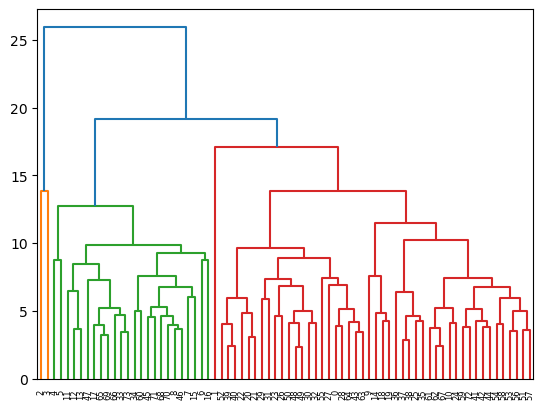

In [92]:
_ = dendrogram(linkage_matrix)

In [93]:
morphotope_labels = fcluster(linkage_matrix, t=10, criterion='distance')

In [94]:
final_labels = clusterer.labels_.replace(pd.Series(morphotope_labels, index=grouped_data.index).to_dict())
final_labels

0        3
1        3
2        3
3        3
4        3
        ..
13893    9
13894    5
13895    5
13896    5
13897    5
Length: 13898, dtype: int64

In [96]:
# buildings[["geometry"]].explore(
#     column=final_labels, categorical=True, legend=True
# )